## ***Data Cleaning and Feature Engineering***

### Overview
This notebook focuses on cleaning the raw scraped dataset, handling missing and inconsistent values, transforming columns into usable formats, and creating new meaningful features for analysis and machine learning.

### Workflow
- Load raw CSV dataset
- Remove duplicates and irrelevant records
- Handle missing values
- Clean text and numerical columns
- Standardize product attributes
- Convert data types
- Extract and engineer new features from existing columns
- Prepare final dataset for modeling

### Feature Engineering Examples
- Extract capacity values from product titles
- Identify appliance type from descriptions
- Convert price strings into numerical format
- Generate categorical features from specifications
- Create binary indicators for premium features

### Technologies Used
- Python
- pandas
- NumPy
- Regular Expressions (re)

### Output
The processed dataset is exported as a cleaned CSV file ready for:
- Exploratory Data Analysis (EDA)
- Machine Learning pipelines
- Price prediction models
- Business insights and visualization

In [1]:
# import libraries
import pandas as pd
import numpy as np
import re

In [2]:
# load the parsed data of air conditioners 
raw_df = pd.read_csv("D:/Study/data_science/underpriced-listing-predictor/data/02.parsed/ac_full_parsed.csv")

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      1020 non-null   str  
 1   price     1020 non-null   str  
 2   rating    1020 non-null   str  
 3   ac_type   1020 non-null   str  
 4   capacity  1020 non-null   str  
 5   features  1020 non-null   str  
dtypes: str(6)
memory usage: 294.6 KB
None


In [3]:
print(raw_df.head())

                                                name    price  \
0  Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...  ₹24,990   
1  Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...  ₹22,990   
2  O General ASGG18CGAB-B 1.5 Ton 5 Star Inverter...  ₹67,990   
3  Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...  ₹37,990   
4  Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC  ₹22,990   

            rating   ac_type          capacity  \
0  --rating: 4.65;  Split AC  1.5 Ton Capacity   
1  --rating: 4.55;  Split AC  1.5 Ton Capacity   
2   --rating: 4.1;  Split AC  1.5 Ton Capacity   
3  --rating: 4.55;  Split AC  1.5 Ton Capacity   
4  --rating: 4.55;  Split AC  1.5 Ton Capacity   

                                            features  
0  ['Air Swing, Auto Restart', 'Turbo Mode, Sleep...  
1  ['Hidden Panel Display', '2-Way Air Swing, Aut...  
2  ['LED Panel Display', 'Air Swing, Auto Restart...  
3  ['Hidden Panel Display', '4-Way Air Swing, Aut...  
4  ['Air Swing, Auto Restart', 'D

In [4]:
# Let us check for null values
print(raw_df.isnull().sum()) # Zero null values in our data

name        0
price       0
rating      0
ac_type     0
capacity    0
features    0
dtype: int64


### ***Cleaning Price Column***

In [5]:
raw_df['price'] = pd.to_numeric(raw_df['price'].str.replace('[₹,]', '', regex=True), errors='coerce')

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      1020 non-null   str  
 1   price     1020 non-null   int64
 2   rating    1020 non-null   str  
 3   ac_type   1020 non-null   str  
 4   capacity  1020 non-null   str  
 5   features  1020 non-null   str  
dtypes: int64(1), str(5)
memory usage: 285.7 KB
None


### ***Cleaning User Rating Column***

In [6]:
# Rename `rating` to `user_rating` BEFORE cleaning so the column position
# stays at index 2 — the later loop `for feat in raw_df.columns[5:]` would
# otherwise drop the freshly-created `user_rating` (floats have many unique
# values, each with a tiny proportion, which trips the <10% minority filter).
raw_df = raw_df.rename(columns={'rating': 'user_rating'})

raw_df['user_rating'] = (
    raw_df['user_rating']
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(np.float32)
)

print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1020 non-null   str    
 1   price        1020 non-null   int64  
 2   user_rating  1020 non-null   float32
 3   ac_type      1020 non-null   str    
 4   capacity     1020 non-null   str    
 5   features     1020 non-null   str    
dtypes: float32(1), int64(1), str(4)
memory usage: 267.4 KB
None


### ***Cleaning AC Type Column***

In [7]:
raw_df['ac_type'] = raw_df['ac_type'].str.split(" ").str[0].astype('str')
print(raw_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1020 non-null   str    
 1   price        1020 non-null   int64  
 2   user_rating  1020 non-null   float32
 3   ac_type      1020 non-null   str    
 4   capacity     1020 non-null   str    
 5   features     1020 non-null   str    
dtypes: float32(1), int64(1), str(4)
memory usage: 264.4 KB
None


In [8]:
print(raw_df['ac_type'].value_counts())

ac_type
Split       905
Window      107
Cassette      4
Tower         2
Portable      1
1.5           1
Name: count, dtype: int64


**There are categories of ACs which are very less in comparison to Split or Window**
- What we can do is we can use a threshold for Different categories of ACs
- Suppose We set Threshold = 100 i.e AC Category >100 will be kept other ACs will be dropped automatically.

**This helps us when we scale the data by scraping more (if needed), then our pipeline will remain perfect.**

In [9]:
counts = raw_df['ac_type'].value_counts()

valid_types = counts[counts >= 100].index

raw_df = raw_df[raw_df['ac_type'].isin(valid_types)]
print(raw_df.ac_type.value_counts()) # Only two Categories are left for now!!

ac_type
Split     905
Window    107
Name: count, dtype: int64


### ***Cleaning Capacity Column***

In [10]:
raw_df['capacity'] = raw_df['capacity'].str.split(" ").str[0].astype(np.float32)

print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1012 non-null   str    
 1   price        1012 non-null   int64  
 2   user_rating  1012 non-null   float32
 3   ac_type      1012 non-null   str    
 4   capacity     1012 non-null   float32
 5   features     1012 non-null   str    
dtypes: float32(2), int64(1), str(3)
memory usage: 251.4 KB
None


Axes(0.125,0.11;0.775x0.77)


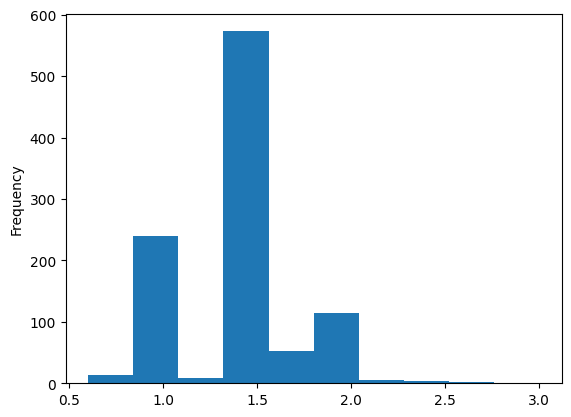

In [11]:
print(raw_df['capacity'].plot(kind='hist'))

In [12]:
print(raw_df['capacity'].value_counts())

capacity
1.50    568
1.00    236
2.00    113
1.60     28
1.80     16
0.80     11
1.70      6
1.40      5
1.20      4
2.50      4
0.90      3
1.30      3
2.60      2
2.20      2
0.75      1
2.15      1
0.60      1
2.25      1
1.75      1
2.10      1
1.65      1
3.00      1
0.70      1
1.25      1
2.02      1
Name: count, dtype: int64


- This rounds the data into standard sizes !! capacity is a numerical quantity so Do not interpret it as Categorical Feature

In [13]:
# import numpy as np

# def round_to_standard_capacity(val):
#     # Standard AC sizes in the market
#     standard = [0.75, 1.0, 1.2, 1.5, 1.6, 1.8, 2.0, 2.5, 3.0]
#     return min(standard, key=lambda x: abs(x - val))

# raw_df['capacity'] = raw_df['capacity'].apply(round_to_standard_capacity)

# raw_df['capacity'] = raw_df['capacity'].astype(np.float32)
# print(raw_df['capacity'].value_counts())

- Well, this is Future me, I cleaned the column too aggressively and now at EDA I am facing some issues. 
- Capacity is kept as a continuous float (24 distinct values). Rounding to standard tiers was tried but created cross-tier contamination and a phantom 0.75T cluster; reverted to raw values so tree models can find natural splits.

### ***Cleaning Features Column***

- We will find the Top features which are present in most of the ACs. Then we create binary column for each such feature

In [14]:
import ast

raw_df['features'] = raw_df['features'].apply(ast.literal_eval) # This converts dtype of features column into list

In [15]:
raw_df['features'].value_counts()

features
[Hidden Panel Display, 4-Way Air Swing, Auto Restart, Wi-Fi Connectivity, APP Control, Voice Control, Dehumidification, Inverter, Sleep Mode, Dust Filter]                    22
[LED Panel Display, Air Swing, Auto Restart, Dehumidification, Inverter, Turbo Mode, Sleep Mode, Dust Filter, Self Diagnosis]                                                 21
[4-Way Air Swing, Auto Restart, Dehumidification, Inverter, Turbo Mode, Sleep Mode, Dust Filter, Self Diagnosis, Night Glow Buttons]                                          18
[Air Swing, Auto Restart, Dehumidification, Inverter, Sleep Mode, Dust Filter, Auto Clean, 3 Star Rating]                                                                     17
[Hidden LED Panel Display, 4-Way Air Swing, Auto Restart, Wi-Fi Connectivity, APP Control, Voice Control, Dehumidification, Inverter, Turbo Mode, Sleep Mode, Dust Filter]    17
                                                                                                          

- We see features like dust filter appear more than one place since they were grouped with other features inside the string.
- Thus we must separate out each feature and create a single list for each row with all features in a list added separately

In [16]:
def clean_features(feature_list):
    cleaned = []

    for item in feature_list:
        split_items = item.split(',')

        for feat in split_items:
            cleaned.append(feat.strip())

    return cleaned

raw_df['features'] = raw_df['features'].apply(clean_features)

In [17]:
print(raw_df['features'][760])

['Hidden Panel Display', '4-Way Air Swing', 'Auto Restart', 'Dehumidification', 'Inverter', 'Turbo Mode', 'Sleep Mode', 'Dust Filter', 'Self Diagnosis']


In [18]:
# Apply the counter to check the 20 most common Features
from collections import Counter

all_features = []

for row in raw_df['features']:
    all_features.extend(row)

best_features = Counter(all_features).most_common(20)
binary_feat = []
for i in best_features:
    binary_feat.append(i[0])

print(binary_feat)

['Dust Filter', 'Auto Restart', 'Sleep Mode', 'Dehumidification', 'Inverter', 'Turbo Mode', 'Air Swing', 'Self Diagnosis', '4-Way Air Swing', 'Memory Feature', 'LED Panel Display', '3 Star Rating', 'Night Glow Buttons', 'Wi-Fi Connectivity', 'APP Control', 'Auto Clean', 'Hidden Panel Display', 'Voice Control', 'PM 2.5 Filter', 'Hidden LED Panel Display']


**We will add these 20 Features as our Binary Features**

In [19]:
for feat in binary_feat:
    raw_df[feat] = raw_df['features'].apply(lambda x : int(feat in x))

print(raw_df.info())


<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      1012 non-null   str    
 1   price                     1012 non-null   int64  
 2   user_rating               1012 non-null   float32
 3   ac_type                   1012 non-null   str    
 4   capacity                  1012 non-null   float32
 5   features                  1012 non-null   object 
 6   Dust Filter               1012 non-null   int64  
 7   Auto Restart              1012 non-null   int64  
 8   Sleep Mode                1012 non-null   int64  
 9   Dehumidification          1012 non-null   int64  
 10  Inverter                  1012 non-null   int64  
 11  Turbo Mode                1012 non-null   int64  
 12  Air Swing                 1012 non-null   int64  
 13  Self Diagnosis            1012 non-null   int64  
 14  4-Way Air Swing         

In [20]:
print(raw_df['Air Swing'].value_counts()) # We have correctly created binary features of TopFeatures

Air Swing
0    524
1    488
Name: count, dtype: int64


In [21]:
raw_df = raw_df.drop('features' , axis = 1)

print(len(raw_df.columns))

25


In [22]:
for feat in raw_df.columns.to_list()[5:] :
    print(raw_df[feat].value_counts())
    print(f"\n{'-'*50}\n")

Dust Filter
1    992
0     20
Name: count, dtype: int64

--------------------------------------------------

Auto Restart
1    985
0     27
Name: count, dtype: int64

--------------------------------------------------

Sleep Mode
1    948
0     64
Name: count, dtype: int64

--------------------------------------------------

Dehumidification
1    885
0    127
Name: count, dtype: int64

--------------------------------------------------

Inverter
1    876
0    136
Name: count, dtype: int64

--------------------------------------------------

Turbo Mode
1    650
0    362
Name: count, dtype: int64

--------------------------------------------------

Air Swing
0    524
1    488
Name: count, dtype: int64

--------------------------------------------------

Self Diagnosis
0    531
1    481
Name: count, dtype: int64

--------------------------------------------------

4-Way Air Swing
0    591
1    421
Name: count, dtype: int64

--------------------------------------------------

Memory Featur

### ***Plan of Action***
- (i) Drop the columns having minority category value < 10% since they have really bad distribution and the Feature won't have much significance on Target.

- (ii) Merge 4-Way Air Swing and Air Swing Features into 1 Feature since they are similar features. Keep 1 if row contains either of the features otherwise 0.

- (iii) Remove 3 Star Rating and Inverter Feature for now. These will be added back when we get the data from Name Column since the name has values for both AC Rating and Invertor(binary categorical type).


In [23]:
# Dropping feature columns where minority category is < 10% 

count = 0
for feat in raw_df.columns.to_list()[5:]:
    if (raw_df[feat].value_counts(normalize=True)<.10).sum() >0:
        count+=1
        raw_df = raw_df.drop(feat , axis=1)
print(count)

4


In [24]:
# Remove 3 Star Rating and Invertor Column for now; we'll add them later 
raw_df = raw_df.drop(['3 Star Rating','Inverter'] , axis = 1)

print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1012 non-null   str    
 1   price                 1012 non-null   int64  
 2   user_rating           1012 non-null   float32
 3   ac_type               1012 non-null   str    
 4   capacity              1012 non-null   float32
 5   Dehumidification      1012 non-null   int64  
 6   Turbo Mode            1012 non-null   int64  
 7   Air Swing             1012 non-null   int64  
 8   Self Diagnosis        1012 non-null   int64  
 9   4-Way Air Swing       1012 non-null   int64  
 10  Memory Feature        1012 non-null   int64  
 11  LED Panel Display     1012 non-null   int64  
 12  Night Glow Buttons    1012 non-null   int64  
 13  Wi-Fi Connectivity    1012 non-null   int64  
 14  APP Control           1012 non-null   int64  
 15  Auto Clean            1012 non-null  

In [25]:
# Merging the data of 4 Way Air Swing and Air Swing Features; Be aware that a few column may have both so we need to check if either is present.

raw_df['Air Swing'] = (raw_df['4-Way Air Swing'] + raw_df['Air Swing']).clip(upper=1)
raw_df = raw_df.drop('4-Way Air Swing' , axis=1)

In [26]:
print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1012 non-null   str    
 1   price                 1012 non-null   int64  
 2   user_rating           1012 non-null   float32
 3   ac_type               1012 non-null   str    
 4   capacity              1012 non-null   float32
 5   Dehumidification      1012 non-null   int64  
 6   Turbo Mode            1012 non-null   int64  
 7   Air Swing             1012 non-null   int64  
 8   Self Diagnosis        1012 non-null   int64  
 9   Memory Feature        1012 non-null   int64  
 10  LED Panel Display     1012 non-null   int64  
 11  Night Glow Buttons    1012 non-null   int64  
 12  Wi-Fi Connectivity    1012 non-null   int64  
 13  APP Control           1012 non-null   int64  
 14  Auto Clean            1012 non-null   int64  
 15  Hidden Panel Display  1012 non-null  

### ***Cleaning Name Column***

In [27]:
raw_df['name']

0       Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...
1       Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...
2       O General ASGG18CGAB-B 1.5 Ton 5 Star Inverter...
3       Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...
4       Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC
                              ...                        
1015    Blue Star IC512EBTU 1 Ton 5 Star Split Inverte...
1016    Hitachi RSNG318HDEAZ2 1.5 Ton 3 Star Split Inv...
1017    Samsung AR18TY3QBPU 1.5 Ton 3 Star Split Inver...
1018      Hitachi RSM318HDDO 1.5 Ton 3 Star 2019 Split AC
1019    Samsung AR18TY5QAWK 1.5 Ton 5 Star 2019 Split ...
Name: name, Length: 1012, dtype: str

- ***Next Very Important***                                                                                                                 
-Convert star ratings into separate numeric feature                                                                                         
-**Instead of:** 3 Star Rating, 5 Star Rating                                                                                       
-**Create:** energy_rating                                                                                                              
energy_rating                                                                                                                               
3                                                                                                                                   
5                                                                                                                                           

This is much better for ML.

In [28]:
# Let us create a Feature Inverter(binary categorical) If name has Inverter -> 1 else 0
raw_df['inverter'] = raw_df['name'].str.contains('Inverter').astype(np.int32)


In [29]:
raw_df['name']

0       Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...
1       Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...
2       O General ASGG18CGAB-B 1.5 Ton 5 Star Inverter...
3       Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...
4       Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC
                              ...                        
1015    Blue Star IC512EBTU 1 Ton 5 Star Split Inverte...
1016    Hitachi RSNG318HDEAZ2 1.5 Ton 3 Star Split Inv...
1017    Samsung AR18TY3QBPU 1.5 Ton 3 Star Split Inver...
1018      Hitachi RSM318HDDO 1.5 Ton 3 Star 2019 Split AC
1019    Samsung AR18TY5QAWK 1.5 Ton 5 Star 2019 Split ...
Name: name, Length: 1012, dtype: str

In [30]:
# Using regex to extract star ratings from the name

raw_df['star_rating'] = (
    raw_df['name']
    .str.extract(r'(\d)\s*Star')
    .astype('Int64')
)

In [31]:
print(raw_df.info())


<class 'pandas.DataFrame'>
Index: 1012 entries, 0 to 1019
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1012 non-null   str    
 1   price                 1012 non-null   int64  
 2   user_rating           1012 non-null   float32
 3   ac_type               1012 non-null   str    
 4   capacity              1012 non-null   float32
 5   Dehumidification      1012 non-null   int64  
 6   Turbo Mode            1012 non-null   int64  
 7   Air Swing             1012 non-null   int64  
 8   Self Diagnosis        1012 non-null   int64  
 9   Memory Feature        1012 non-null   int64  
 10  LED Panel Display     1012 non-null   int64  
 11  Night Glow Buttons    1012 non-null   int64  
 12  Wi-Fi Connectivity    1012 non-null   int64  
 13  APP Control           1012 non-null   int64  
 14  Auto Clean            1012 non-null   int64  
 15  Hidden Panel Display  1012 non-null  

In [32]:
# removing the duplicate rows!!
raw_df = raw_df.drop_duplicates()

print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1019
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1009 non-null   str    
 1   price                 1009 non-null   int64  
 2   user_rating           1009 non-null   float32
 3   ac_type               1009 non-null   str    
 4   capacity              1009 non-null   float32
 5   Dehumidification      1009 non-null   int64  
 6   Turbo Mode            1009 non-null   int64  
 7   Air Swing             1009 non-null   int64  
 8   Self Diagnosis        1009 non-null   int64  
 9   Memory Feature        1009 non-null   int64  
 10  LED Panel Display     1009 non-null   int64  
 11  Night Glow Buttons    1009 non-null   int64  
 12  Wi-Fi Connectivity    1009 non-null   int64  
 13  APP Control           1009 non-null   int64  
 14  Auto Clean            1009 non-null   int64  
 15  Hidden Panel Display  1009 non-null  

In [33]:
brands = raw_df['name'].str.split().str[0].value_counts().index.to_list()

- What I did here is that I found The first name of the brand, if the name was incomplete, I manually completed it and then saved it inside brands list again to perform regex code on the raw_df['name'] Series.

In [34]:
brands = [
    'Blue Star',
    'Panasonic',
    'Godrej',
    'Voltas',
    'Lloyd',
    'Hitachi',
    'Daikin',
    'Haier',
    'Carrier',
    'LG',
    'Samsung',
    'Whirlpool',
    'IFB',
    'Croma',
    'Mitsubishi',
    'O General',
    'MarQ',
    'Midea',
    'Sharp',
    'Onida',
    'Realme',
    'Hisense',
    'TCL',
    'Cruise',
    'Motorola',
    'BPL',
    'Sansui',
    'Candy',
    'iMee',
    'Electrolux',
    'Thomson',
    'Acer',
    'Toshiba'
]

pattern = '^(' + '|'.join(brands) + ')'


raw_df['brand'] = raw_df['name'].str.extract(pattern)


### ***Extracting Model Year from the data as it is very important column***

In [35]:
raw_df['name'].str.split()

0       [Whirlpool, SAI18B52MCD1, 1.5, Ton, 5, Star, I...
1       [Carrier, CAI18ER3R34F0, 1.5, Ton, 3, Star, 20...
2       [O, General, ASGG18CGAB-B, 1.5, Ton, 5, Star, ...
3       [Haier, HSU18V-POW5BN-INV, 1.5, Ton, 5, Star, ...
4       [Voltas, 183V, XAZX, 1.5, Ton, 3, Star, Split,...
                              ...                        
1015    [Blue, Star, IC512EBTU, 1, Ton, 5, Star, Split...
1016    [Hitachi, RSNG318HDEAZ2, 1.5, Ton, 3, Star, Sp...
1017    [Samsung, AR18TY3QBPU, 1.5, Ton, 3, Star, Spli...
1018    [Hitachi, RSM318HDDO, 1.5, Ton, 3, Star, 2019,...
1019    [Samsung, AR18TY5QAWK, 1.5, Ton, 5, Star, 2019...
Name: name, Length: 1009, dtype: object

In [36]:
raw_df['model_year'] = raw_df['name'].str.extract(r'\b(201[0-9]|202[0-9])\b').astype('Int64')

In [37]:
print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1019
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1009 non-null   str    
 1   price                 1009 non-null   int64  
 2   user_rating           1009 non-null   float32
 3   ac_type               1009 non-null   str    
 4   capacity              1009 non-null   float32
 5   Dehumidification      1009 non-null   int64  
 6   Turbo Mode            1009 non-null   int64  
 7   Air Swing             1009 non-null   int64  
 8   Self Diagnosis        1009 non-null   int64  
 9   Memory Feature        1009 non-null   int64  
 10  LED Panel Display     1009 non-null   int64  
 11  Night Glow Buttons    1009 non-null   int64  
 12  Wi-Fi Connectivity    1009 non-null   int64  
 13  APP Control           1009 non-null   int64  
 14  Auto Clean            1009 non-null   int64  
 15  Hidden Panel Display  1009 non-null  

### ***Adding Product type as AC in a new column***

In [38]:
raw_df['product'] = raw_df['name'].str.split().str[-1].str.strip()

raw_df['product'].value_counts()

product
AC         1005
Ac            3
(White)       1
Name: count, dtype: int64

- We see that some product name is Not correctly written, so I have written it correctly

In [39]:
raw_df['product'] = 'AC'

raw_df.info()

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1019
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1009 non-null   str    
 1   price                 1009 non-null   int64  
 2   user_rating           1009 non-null   float32
 3   ac_type               1009 non-null   str    
 4   capacity              1009 non-null   float32
 5   Dehumidification      1009 non-null   int64  
 6   Turbo Mode            1009 non-null   int64  
 7   Air Swing             1009 non-null   int64  
 8   Self Diagnosis        1009 non-null   int64  
 9   Memory Feature        1009 non-null   int64  
 10  LED Panel Display     1009 non-null   int64  
 11  Night Glow Buttons    1009 non-null   int64  
 12  Wi-Fi Connectivity    1009 non-null   int64  
 13  APP Control           1009 non-null   int64  
 14  Auto Clean            1009 non-null   int64  
 15  Hidden Panel Display  1009 non-null  

In [40]:
# Switching the brand column to Index 1 just to make dataset look better
brand = raw_df.pop('brand')
product = raw_df.pop('product')
model_year = raw_df.pop('model_year')
raw_df.insert(1, 'brand', brand)
raw_df.insert(2, 'product', product)
raw_df.insert(2, 'model_year', model_year)

raw_df.drop('name' , axis=1 , inplace =True)
print(raw_df.info())

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1019
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 997 non-null    str    
 1   model_year            842 non-null    Int64  
 2   product               1009 non-null   str    
 3   price                 1009 non-null   int64  
 4   user_rating           1009 non-null   float32
 5   ac_type               1009 non-null   str    
 6   capacity              1009 non-null   float32
 7   Dehumidification      1009 non-null   int64  
 8   Turbo Mode            1009 non-null   int64  
 9   Air Swing             1009 non-null   int64  
 10  Self Diagnosis        1009 non-null   int64  
 11  Memory Feature        1009 non-null   int64  
 12  LED Panel Display     1009 non-null   int64  
 13  Night Glow Buttons    1009 non-null   int64  
 14  Wi-Fi Connectivity    1009 non-null   int64  
 15  APP Control           1009 non-null  

In [41]:
final_df = raw_df.copy()

In [42]:
# Let us remove the rows which have null values
final_df = final_df.dropna(subset=['brand','star_rating'], how='any')

print(final_df.isnull().sum().sum())

163


In [43]:
print(final_df.info())

<class 'pandas.DataFrame'>
Index: 994 entries, 0 to 1019
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 994 non-null    str    
 1   model_year            831 non-null    Int64  
 2   product               994 non-null    str    
 3   price                 994 non-null    int64  
 4   user_rating           994 non-null    float32
 5   ac_type               994 non-null    str    
 6   capacity              994 non-null    float32
 7   Dehumidification      994 non-null    int64  
 8   Turbo Mode            994 non-null    int64  
 9   Air Swing             994 non-null    int64  
 10  Self Diagnosis        994 non-null    int64  
 11  Memory Feature        994 non-null    int64  
 12  LED Panel Display     994 non-null    int64  
 13  Night Glow Buttons    994 non-null    int64  
 14  Wi-Fi Connectivity    994 non-null    int64  
 15  APP Control           994 non-null    

In [44]:
# Saving the dataset into parquet file
final_df.to_parquet("D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.parquet", index=False) 
final_df.to_csv("D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.csv", index=False , header=True) 

### ***Cleaning + Feature Engineering Part of AC Parsed Dataset Completed***